In [1]:
%matplotlib inline

In [2]:
import pandas as pd
from pandas import DataFrame

from typing import Dict, Tuple, Union

import numpy as np

# For visualizations
import matplotlib.pyplot as plt 
import seaborn as sns

# For API key 
import os
from dotenv import load_dotenv
import requests

# Data description, acquisition, cleaning and preprocessing

## Bird data


The data on birds will be gathered from the eBird database. Information about the dataset features has been found through the eBird website, eBird API information, the best practices guide available on the eBird website, and the community eBird forum board. 

Citizen science, especially species observation data like those from eBird, is playing a vital role in ecological research and conservation. eBird is the world’s largest biological citizen science program, with over a billion bird observations globally. Its value lies in its wide coverage, large volume, open access, and applicability to diverse ecological questions, such as phenology, species distributions, and conservation.

The eBird data is semi-structured in the form of checklists and provides information on 

| Feature                        | Description                                                   |
| ------------------------------ | ------------------------------------------------------------- |
| **LAST EDITED DATE**           | Date when the observation record was last updated.            |
| **TAXONOMIC ORDER**            | Numeric ordering of species following eBird taxonomy.         |
| **CATEGORY**                   | Taxonomic category (e.g., species, subspecies, hybrid, form). |
| **TAXON CONCEPT ID**           | Unique eBird ID for the taxonomic concept.                    |
| **COMMON NAME**                | Standard common name of the bird.                             |
| **SCIENTIFIC NAME**            | Latin (binomial) name of the bird.                            |
| **SUBSPECIES COMMON NAME**     | Common name of the subspecies (if recorded).                  |
| **SUBSPECIES SCIENTIFIC NAME** | Latin name of the subspecies (if recorded).                   |
| **EXOTIC CODE**                | Code indicating non-native status and origin type.            |
| **OBSERVATION COUNT**          | Number of individuals observed. If uncertain - "X" to denote presence            |
| **BREEDING CODE**              | Code describing breeding evidence.                            |
| **BREEDING CATEGORY**          | General category of breeding evidence.                        |
| **BEHAVIOR CODE**              | Code for observed behavior (e.g., feeding, singing).          |
| **AGE/SEX**                    | Age and/or sex breakdown of the observed individuals.         |
| **COUNTRY**                    | Country where the observation occurred.                       |
| **COUNTRY CODE**               | ISO country code.                                             |
| **STATE**                      | State, province, or region name.                              |
| **STATE CODE**                 | ISO or eBird state/province code.                             |
| **COUNTY**                     | County or district name.                                      |
| **COUNTY CODE**                | eBird county/district code.                                   |
| **IBA CODE**                   | Important Bird Area code.                                     |
| **BCR CODE**                   | Bird Conservation Region code.                                |
| **USFWS CODE**                 | U.S. Fish and Wildlife Service region code.                   |
| **ATLAS BLOCK**                | Atlas project survey block ID.                                |
| **LOCALITY**                   | Name of the location where the bird was observed.             |
| **LOCALITY ID**                | Unique eBird ID for the location.                             |
| **LOCALITY TYPE**              | Type of location (e.g., hotspot, personal location).          |
| **LATITUDE**                   | Latitude coordinate of observation.                           |
| **LONGITUDE**                  | Longitude coordinate of observation.                          |
| **OBSERVATION DATE**           | Date of the observation.                                      |
| **TIME OBSERVATIONS STARTED**  | Start time of the observation.                                |
| **OBSERVER ID**                | Unique eBird ID of the observer.                              |
| **OBSERVER ORCID ID**          | Observer’s ORCID researcher identifier.                       |
| **SAMPLING EVENT IDENTIFIER**  | Unique ID for the checklist/survey event.                     |
| **OBSERVATION TYPE**           | Type of observation record (e.g., incidental, stationary).    |
| **PROTOCOL NAME**              | Name of the observation protocol used.                        |
| **PROTOCOL CODE**              | Code representing the protocol.                               |
| **PROJECT NAMES**              | Names of projects associated with the checklist.              |
| **PROJECT IDENTIFIERS**        | IDs for associated projects.                                  |
| **DURATION MINUTES**           | Length of the observation period in minutes.                  |
| **EFFORT DISTANCE KM**         | Distance covered during the observation in kilometers.        |
| **EFFORT AREA HA**             | Area covered during the observation in hectares.              |
| **NUMBER OBSERVERS**           | Number of observers participating.                            |
| **ALL SPECIES REPORTED**       | Whether the checklist reports all species seen/heard.         |
| **GROUP IDENTIFIER**           | ID for grouping related checklists.                           |
| **HAS MEDIA**                  | Indicates if photos/audio are attached.                       |
| **APPROVED**                   | Whether the record was accepted in review.                    |
| **REVIEWED**                   | Whether the record has been reviewed.                         |
| **REASON**                     | Reason for review decision (if applicable).                   |
| **CHECKLIST COMMENTS**         | Notes about the entire checklist.                             |
| **SPECIES COMMENTS**           | Notes about the specific species observation.                 |


Each observer ("**birder**") is able to submit checklists and inform on the above features of their checklist, usually through a mobile app. None of these features apart from date and location are mandatory, so the possibility exists to submit an empty checklist with no observed birds. Checklists are also available to be viewed online.

<figure>
  <img src="../pictures/own_checklist.jpg" alt="Example checklist" style="width:80%">
  <figcaption><b>Fig.1</b> <strong> Example checklist - webview <br> Source link: own checklist screenshot </figcaption>
</figure>

The eBird checklists distinguish themselves from other similar sources by three elements (eBird website, 2025) - the survey protocol is specified (whether this is a traveling, stationary or incidental observation); effort can be estimated by the travelled location, duration of travel, and number of observers present in the group; completeness of checklists is reported (i.e. whether all species have been reported that the birder has spotted).

This allows for: 
- **robustness analysis** - based on whether a checklist is complete (all species are reported), and derived from the **effort exhibitted** during the birding trip, and the **probable correctness** of the observation (as incidental observations, or those done from a fast moving vehicle are generally less trustworthy, especially from inexperienced birders)

- **zero-filling**, i.e. from all (complete) checklists, those that do not contain a species of interest are deemed to contain zero observations of that species, and thus, frequency of observations of the species of interest could be inferred over a designated time period.

eBird uses its own taxonomic system, which is updated annually, and experts review taxonomic hypotheses, and presented records regularly. This allows for more granularity in research, for example we could analyse data for the eastern and western populations of a species separately, combine species by genus, or explore various subspecies of that genus, including hybrids. 

However, to draw reliable conclusions from eBird data, researchers must address several inherent challenges, including:

**Taxonomic bias** – Participants tend to favor certain species

**Spatial bias** – Observations cluster near participants’ homes or popular areas

**Temporal bias** – Sampling often happens on weekends or during peak birding seasons

**Class imbalance** – Rare species are under-represented

**Spatial precision** – Checklist locations may be imprecise, especially for traveling or hotspot-assigned checklists

**Variation in detectability/effort** – Observation effort varies widely (time, weather, observers, etc.), but eBird’s semi-structured protocols allow researchers to account for this variation.

### eBird data acquisition

The eBird data is available in the form of downloads from the Basic Dataset (EBD), which could be chosen to include Sampling Event Data (SED). While EBD contains only information for a certain species, region and/or date range, SED data is a complete information of all checlists, their effort and completeness, which is necessary for zero-filling purposes. Link from the eBird website to download EBD (requires registration) could be found [here](https://ebird.org/data/download/ebd).


### eBird data loading, cleaning and preprocessing

The eBird data is in the form of tab-separated text files, and can be easily read with the ```read_csv``` function from the ```pandas``` library.

We begin by defining the paths of the downloaded data for EBD - ```ebd_path``` and SED - ```sed_path```. I have downloaded data for **all** species in the whole country of **Bulgaria** for the period of January 01 1990 until June 30 2025. 

In [3]:
ebd_path = "../data/raw/eBird_data/ebd_BG_199001_202506_smp_relJun-2025.txt"
sed_path = "../data/raw/eBird_data/ebd_BG_199001_202506_smp_relJun-2025_sampling.txt"

While eBird data is generally well-maintained, cleaning is necessary for the purposes of different analyses. 

For my analysis, I will do the following cleaning steps: 

- I will leave only one checklist per group. This is because all checklists with the same group identifier are exactly the same, and describe the exact same observations, effort and protocols. Group identifiers are usually used when for instance a group of birdwatchers has an organized tour to a region.

- I will only be interested in birds at the species level. Thus, I will exclude all exotic species, hybrids and population-dependent subspecies. In the ``category``` feature I have the following possible options for each observation:

    - Species: Research - accepted species, e.g., Tundra Swan

    - ISSF (Identifiable Sub-specific Group): A recognizable subspecies or group, e.g., Tundra Swan (Bewick’s)

    - Hybrid: A cross between two species, e.g., Tundra x Trumpeter Swan (hybrid)

    - Intergrade: A hybrid between subspecies or sub-specific groups, e.g., Tundra Swan (Whistling x Bewick’s)

    - Spuh: Broad, often genus-level ID when the species isn't certain, e.g., swan sp.

    - Slash: ID narrowed to two species but not precisely determined, e.g., Tundra/Trumpeter Swan

    - Domestic: A domesticated form with distinct plumage, not part of wild bird lists, e.g., Mallard (Domestic type)

    - Form: Miscellaneous taxa—distinct forms, e.g., Red-tailed Hawk (abieticola)
 
    Filtering my dataset to include only the categories ```species```, ```issf``` (identifiable subspecies or groups), and ```form``` makes sense for most scientific and ecological analyses because these categories represent well-defined taxa that support reliable and meaningful inference.


- I will remove species for which observations are less or equal to $20$ for the whole period $1990 - 2025$. This is an initial quality control step. This threshold aligns with reported minimums for reliable distribution modeling (e.g., [$17–30$ records for narrow vs. widespread distributions](https://www.scielo.br/j/aabc/a/GyphZPPwgPx6mZ8zVcQnGQC/?lang=en)).


This will be carried out by the ```clean_ebird_data``` function below. 

In [4]:
def clean_ebird_data(df: DataFrame) -> DataFrame:
    """
    Cleans an eBird dataset by applying the following filters:
    
    1. Drops duplicate checklists identified by 'group_identifier', 
       keeping only the first entry per group.
    2. Keeps only records where 'category' is one of ['form', 'issf', 'species'].
    3. Removes records with non-empty 'exotic_code' values.
    4. Removes species with fewer than 20 total observations in the dataset.
    
    Parameters:
        df (pd.DataFrame): The raw eBird data.

    Returns:
        pd.DataFrame: A cleaned DataFrame with filters applied.
    """
    df = df.copy()

    # Drop duplicates by group identifier
    if 'group_identifier' in df.columns:
        with_group = df[df['group_identifier'].notna()]
        without_group = df[df['group_identifier'].isna()]
        with_group = (
            with_group
            .sort_values('observation_date')
            .drop_duplicates(subset='group_identifier', keep='first') # Keep only the first occurrence within each group as it is the same as the rest 
        )
        df = pd.concat([with_group, without_group], ignore_index=True)

    # Keep only allowed categories
    if 'category' in df.columns:
        allowed_categories = {'form', 'issf', 'species'}
        df = df[df['category'].isin(allowed_categories)]

    # Keep only rows where 'exotic_code' is empty
    if 'exotic_code' in df.columns:
        df = df[df['exotic_code'].isna()]

    # Remove species with fewer than 20 observations
    if 'scientific_name' in df.columns:
        species_counts = df['scientific_name'].value_counts()
        valid_species = species_counts[species_counts >= 20].index
        df = df[df['scientific_name'].isin(valid_species)]

    return df

I will now use my API key to check the county codes in more detail. I want to ultimately be able to assign the observation location to one of the three flyways in Bulgaria.

As the reader may not have an API key of their own, I will paste the response below: 

[{'code': 'BG-01', 'name': 'Blagoevgrad'}, {'code': 'BG-02', 'name': 'Burgas'}, {'code': 'BG-08', 'name': 'Dobrich'}, {'code': 'BG-07', 'name': 'Gabrovo'}, {'code': 'BG-26', 'name': 'Haskovo'}, {'code': 'BG-09', 'name': 'Kardzhali'}, {'code': 'BG-10', 'name': 'Kyustendil'}, {'code': 'BG-11', 'name': 'Lovech'}, {'code': 'BG-12', 'name': 'Montana'}, {'code': 'BG-13', 'name': 'Pazardzhik'}, {'code': 'BG-14', 'name': 'Pernik'}, {'code': 'BG-15', 'name': 'Pleven'}, {'code': 'BG-16', 'name': 'Plovdiv'}, {'code': 'BG-17', 'name': 'Razgrad'}, {'code': 'BG-18', 'name': 'Ruse'}, {'code': 'BG-27', 'name': 'Shumen'}, {'code': 'BG-19', 'name': 'Silistra'}, {'code': 'BG-20', 'name': 'Sliven'}, {'code': 'BG-21', 'name': 'Smolyan'}, {'code': 'BG-23', 'name': 'Sofia'}, {'code': 'BG-22', 'name': 'Sofia-Grad'}, {'code': 'BG-24', 'name': 'Stara Zagora'}, {'code': 'BG-25', 'name': 'Targovishte'}, {'code': 'BG-03', 'name': 'Varna'}, {'code': 'BG-04', 'name': 'Veliko Tarnovo'}, {'code': 'BG-05', 'name': 'Vidin'}, {'code': 'BG-06', 'name': 'Vratsa'}, {'code': 'BG-28', 'name': 'Yambol'}]

In [5]:
# Try to load .env variables
try:
    load_dotenv()
except Exception as e:
    print("Could not load .env file:", e)

# Attempt to get the API key
EBIRD_API_KEY = os.getenv("EBIRD_API_KEY")

# Notify about key availability
if EBIRD_API_KEY:
    print("API key loaded successfully.")
else:
    print("API key not found. API requests below will not work.")

# Prepare request headers only if the key is available
headers = {}

if EBIRD_API_KEY:
    headers = {
        "X-eBirdApiToken": EBIRD_API_KEY
    }

# Try to call the API
try:
    response = requests.get(
        "https://api.ebird.org/v2/ref/region/list/subnational1/BG",
        headers=headers if EBIRD_API_KEY else None,
        timeout=10  # optional: avoid hanging
    )

    if response.status_code == 200:
        data = response.json()
        print("API call successful.")
        print(data)
    else:
        print(f"API request failed: {response.status_code} - {response.text}")

except requests.exceptions.RequestException as e:
    print("API request error:", e)

API key loaded successfully.
API call successful.
[{'code': 'BG-01', 'name': 'Blagoevgrad'}, {'code': 'BG-02', 'name': 'Burgas'}, {'code': 'BG-08', 'name': 'Dobrich'}, {'code': 'BG-07', 'name': 'Gabrovo'}, {'code': 'BG-26', 'name': 'Haskovo'}, {'code': 'BG-09', 'name': 'Kardzhali'}, {'code': 'BG-10', 'name': 'Kyustendil'}, {'code': 'BG-11', 'name': 'Lovech'}, {'code': 'BG-12', 'name': 'Montana'}, {'code': 'BG-13', 'name': 'Pazardzhik'}, {'code': 'BG-14', 'name': 'Pernik'}, {'code': 'BG-15', 'name': 'Pleven'}, {'code': 'BG-16', 'name': 'Plovdiv'}, {'code': 'BG-17', 'name': 'Razgrad'}, {'code': 'BG-18', 'name': 'Ruse'}, {'code': 'BG-27', 'name': 'Shumen'}, {'code': 'BG-19', 'name': 'Silistra'}, {'code': 'BG-20', 'name': 'Sliven'}, {'code': 'BG-21', 'name': 'Smolyan'}, {'code': 'BG-23', 'name': 'Sofia'}, {'code': 'BG-22', 'name': 'Sofia-Grad'}, {'code': 'BG-24', 'name': 'Stara Zagora'}, {'code': 'BG-25', 'name': 'Targovishte'}, {'code': 'BG-03', 'name': 'Varna'}, {'code': 'BG-04', 'name':

Now I will use a [map of the provinces in Bulgaria](https://en.wikipedia.org/wiki/Provinces_of_Bulgaria) in conjunction with the map of flyways and I will lay them over one another on GIMP with transparency of the upper layer set to $50\%$. 

<figure>
  <img src="../pictures/BG_overlay_provinces.jpg" alt="Overlay image to map provinces to flyways" style="width:50%">
  <figcaption><b>Fig.2</b> <strong>Overlay image to map provinces to flyways</strong> <br> Although a flyway may span multiple provinces, I have adopted the following approximate mapping: as a general rule, provinces encompassing the eastern Danube River nature reserves and the Black Sea coast are assigned to the Via Pontica flyway, while those covering the western Danube reserves, along with the Sofia and Rila mountain areas, fall under Via Aristotelis. This division reflects the close ecological and migratory connections within each region, where the northern sites often serve as final stopovers before birds reach their southern destinations.  <br> <strong>VIA PONTICA</strong>: BG-02, BG-08, BG-03, BG-17, BG-19, BG-18, BG-27 <br> <strong>VIA ARISTOTELIS</strong>: BG-05, BG-12, BG-06, BG-01, BG-14, BG-23, BG-22, BG-10 <br> <strong>VIA BALCANICA</strong>: the rest  <br> Source: Own image </figcaption>
</figure>


I will now use the above information to classify flyways per observation via the ```classify_flyway``` function.

In [6]:
def classify_flyway(df: DataFrame) -> DataFrame:
    """
    Classifies each row in the input DataFrame into a bird migration flyway 
    based on the 'state_code' column.

    Flyway classification:
    - 'via_pontica' for eastern Danube and Black Sea coastal provinces
    - 'via_aristotelis' for western Danube and mountain regions
    - 'via_balcanica' for all other areas

    Parameters:
        df (pd.DataFrame): A DataFrame containing a 'state_code' column.

    Returns:
        pd.DataFrame: A copy of the input DataFrame with an added 'flyway' column.
    """
    df = df.copy()

    # Define sets of state codes for each flyway
    via_pontica = {'BG-02','BG-08','BG-03','BG-17','BG-19','BG-18','BG-27'}
    via_aristotelis = {'BG-05','BG-12','BG-06','BG-01','BG-14','BG-23','BG-22','BG-10'}

    def get_flyway(code: str) -> str:
        if code in via_pontica:
            return 'via_pontica'
        elif code in via_aristotelis:
            return 'via_aristotelis'
        return 'via_balcanica'

    df['flyway'] = df['state_code'].apply(get_flyway)

    return df

To distinguish migratory from resident bird species, I’ll apply a simple classification rule. Ideally, I’d follow the approach of Zaifman et al. (2017) and categorize every species manually, but for this small-scale project I’ll use the following (admittedly imperfect) rule:

- If over $70\%$ of observations occur in October–March, classify the species as a winter resident.

- If over $70\%$ of observations occur in April–September, classify the species as a summer breeder.

- Otherwise, classify the species as a year-round resident.

**Why should this work?**

As already discussed in the [Introduction chapter](Bird_migration_changes_Aneta_project.ipynb#1.Introduction), Bulgaria’s relatively warm climate (by European standards) means that winter migrants may linger longer before heading north to breed. They also may arrive a bit earlier — sometimes right after their breeding season ends. This stretches their wintering period into parts of autumn and even summer. To avoid overlapping months, I’ve assigned the remaining spring–summer months as the indicator for summer breeders, since these species peak in abundance when their young are still dependent.

**Why choose $70\%$ instead of close to $100\%$?**

There are two reasons.
First, some migratory species naturally include individuals that stay put year-round. Andrade et al. (2025) reported that in $1995$, around $18\%$ of the populations they studied remained in Southern Europe all year. This share has since grown, and by $2020$ some species had stopped migrating entirely.

Second, there’s a small but real risk of misclassification by birders. For example, the Mute Swan is both a wintering and year-round resident in Bulgaria (Bulgarian Red Book Digital, 2025), while the Tundra Swan is a strictly wintering migrant here (Via Pontica website, 2025). Inexperienced observers might simply log “swan” in an app, which could lead to summer records of Tundra Swans that are actually misidentified Mute Swans. I consider this risk low thanks to continuous expert and peer review of submitted checklists — e.g., the British Ornithologists’ Union found in 2021 that only $2\%$ of Elaenia reports were incorrect.

I’m also assuming Bulgaria’s climate is similar enough to the Iberian Peninsula’s, as studied by Andrade et al. (2025). As discussed in [this Quora thread](https://www.quora.com/Is-Bulgaria-a-Southern-country-and-does-it-have-a-mild-climate), Bulgaria’s climate has been trending toward a more “southern” profile in recent years. While there are clear differences, both regions share similar daylight hours due to latitude. According to the [Worlddata website](https://www.worlddata.info/climate-comparison.php?r1=bulgaria&r2=spain), Bulgaria experiences colder winters, cooler water temperatures, and lower nighttime temperatures, but sunshine hours are comparable, and warm-season temperatures are not dramatically different once humidity is considered.

Moreover, for some of the species (e.g. summer breeders) the percentage of observations during autumn and winter months could be additionally inflated by the passage and stopovers of migrating summer breeders of the same species from further up north. It is even possible that some of these individuals coming from further up north choose to overwinter in Bulgaria. See [this link from the Green Balkans website](https://greenbalkans.org/bg/Shtyrkeli_prez_zimata-p4144) for an example of white storks which choose to overwinter in Bulgaria.

Given this, I’ll take Andrade et al.’s $18\%$ as a probable proportion of migrants that remain year-round, and add $2\%$ for potential misidentifications (following the BOU), and provide an additional $10\%$ threshold for overwintering birds from further up north, chosen to be roughly half of the combined percentage of proportion of migrants that remain year-round and the misidentifications, as they are less and less frequently observed than local species which cannot migrate due to inability or injury. As for instance [this source](http://www.karlovobg.eu/index.php?option=com_content&view=article&id=9512:2015-12-22-18-09-00) informs, the bird which chose to overwinter in Bulgaria from Poland, is young and [could have been unable to proceed with following the main flock, or incurred an injury](https://besjournals.onlinelibrary.wiley.com/doi/full/10.1111/1365-2656.13641), which made it stop in Bulgaria. 

The above results in a tolerance of roughly $30\%$ for out-of-season records for both summer breeders and winter migrants. Although this threshold may seem fairly arbitrary (due to the lack of quantifiable information online on winter residents which may choose Bulgaria as breeding grounds, or summer breeders which may choose Bulgaria for overwintering), I will proceed with implementing it, as I want it to serve as an initial evidence-based filter, not as a final one. Further classification will be done in the Exploratory Data Analysis part, that will confirm each species separately as winter resident or summer breeder.

All of this assumes that checklist data reliably reflect true bird presence, and that summer and winter migrants behave similarly enough to be treated with the same classification approach.

In [7]:
def classify_seasonality(df: DataFrame) -> DataFrame:
    """
    Classifies bird species in the dataset into seasonal categories based on their 
    observation frequency throughout the year.

    Categories:
    - 'winter_resident': More than 80% of observations occur in Oct–Mar
    - 'summer_breeder' : More than 80% of observations occur in Apr–Sep
    - 'year_round_resident': All other cases

    Parameters:
        df (pd.DataFrame): A DataFrame containing at least 'observation_date' and 'scientific_name'.

    Returns:
        pd.DataFrame: A new DataFrame with an additional 'seasonality' column.
    """
    df = df.copy()
    
    # Extract observation month from the date
    df['month'] = pd.to_datetime(df['observation_date']).dt.month

    # Define month groups
    winter_months = {10, 11, 12, 1, 2, 3}
    summer_months = {4, 5, 6, 7, 8, 9}

    species_class: Dict[str, str] = {}

    # Group by species and calculate seasonal observation ratios
    for species, group in df.groupby('scientific_name'):
        month_ratios = group['month'].value_counts(normalize=True)
        winter_ratio = month_ratios[month_ratios.index.isin(winter_months)].sum()
        summer_ratio = month_ratios[month_ratios.index.isin(summer_months)].sum()

        if winter_ratio > 0.7:
            species_class[species] = 'winter_resident'
        elif summer_ratio > 0.7:
            species_class[species] = 'summer_breeder'
        else:
            species_class[species] = 'year_round_resident'

    # Map the classification back to the DataFrame
    df['seasonality'] = df['scientific_name'].map(species_class)

    return df

Moreover, I expect that there will be birds that migrate **within** the country. For example, I have observed that mute swans from the Beloslav Lake Complex tend to migrate to the city beaches in Varna, as they have better food availability there during winter months (unfortunately, usually junk food from Varna citizens). Thus, I will do the same analysis as the above one but per flyway in the function ```classify_seasonality_by_flyway```. 

In [8]:
def classify_seasonality_by_flyway(df: DataFrame) -> DataFrame:
    """
    Classifies each bird species into seasonal categories within each flyway 
    based on abundance-weighted monthly observation data.

    Categories:
    - 'winter_resident'    : More than 80% of observations in Oct–Mar
    - 'summer_breeder'     : More than 80% of observations in Apr–Sep
    - 'year_round_resident': All other cases

    Parameters:
        df (pd.DataFrame): DataFrame with at least the following columns:
            - 'observation_date'
            - 'scientific_name'
            - 'flyway'
            - 'observation_count' (optional; assumed to be 1 if missing)

    Returns:
        pd.DataFrame: A new DataFrame with an added 'seasonality_flyway' column.
    """
    df = df.copy()

    # Define seasonal month groups
    winter_months = {10, 11, 12, 1, 2, 3}
    summer_months = {4, 5, 6, 7, 8, 9}

    species_flyway_class: Dict[Tuple[str, str], str] = {}

    # Group by species and flyway
    grouped = df.groupby(['scientific_name', 'flyway'])
    for (species, flyway), group in grouped:
        # Calculate normalized (weighted) monthly abundance
        monthly_counts = group.groupby('month')['observation_count'].sum()
        monthly_distribution = monthly_counts / monthly_counts.sum()

        winter_ratio = monthly_distribution[monthly_distribution.index.isin(winter_months)].sum()
        summer_ratio = monthly_distribution[monthly_distribution.index.isin(summer_months)].sum()

        # Assign seasonality class
        if winter_ratio > 0.7:
            seasonality = 'winter_resident'
        elif summer_ratio > 0.7:
            seasonality = 'summer_breeder'
        else:
            seasonality = 'year_round_resident'

        species_flyway_class[(species, flyway)] = seasonality

    # Map classification back to DataFrame
    df['seasonality_flyway'] = df.apply(
        lambda row: species_flyway_class.get((row['scientific_name'], row['flyway'])),
        axis=1
    )

    return df

We are finally ready to integrate all of the above functions, alongside with pythonization of the column names, into ```load_and_prepare_data```. I have also integrated one last check - keep only species that have at least $150$ observations for $5$ consecutive years, with starting year as $2019$. This accounts for roughly $7$ observations per week if we assume a $6$-month observation window per year due to seasonality, or at least once every day (as an average and approximate estimation).

Changing the starting year and/or increasing the consecutive years threshold leaves me only with one winter resident species for analysis. Please keep reading for further information on that.

All cleaning and preprocessing is done according to the already described functions above.

Observed counts "X" are converted to ```NaN```, due the impossibility to determine an actual number of observed species, or whether they have actually being observed at all. "X" is used to denote presence (e.g. if the birder has heard the call of the bird), but not an actual confirmed number of observations.

Observation date is converted date to ```pandas``` ```datetime```. Month, year, week number and season are extracted from the date and saved into separate columns. 

The definition of seasons as full months as opposed to their astronomical start dates is done for simplification, as as also suggested when defining seasons [meteorogically](https://en.wikipedia.org/wiki/Season). 

In [9]:
def load_and_prepare_data(
    ebd_path: str,
    sed_path: str,
    min_obs_threshold: int = 150,
    start_year: int = 2019,
    min_consecutive_years: int = 5
) -> Tuple[DataFrame, DataFrame]:
    """
    Loads, cleans, and filters eBird and sampling event datasets for analysis of 
    migratory bird species, based on seasonal classification and observation thresholds.

    Parameters:
        ebd_path (str): Path to the eBird dataset (.txt or .tsv format).
        sed_path (str): Path to the sampling event dataset (.txt or .tsv format).
        min_obs_threshold (int): Minimum number of observations per species per year.
        start_year (int): Earliest year to consider for seasonal filtering.
        min_consecutive_years (int): Minimum number of consecutive years meeting threshold.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: A tuple of (cleaned eBird DataFrame, cleaned SED DataFrame).
    """
    
    def standardize_columns(df: DataFrame) -> DataFrame:
        return df.rename(columns=lambda col: col.strip().lower().replace(' ', '_').replace('-', '_'))

    def assign_seasonality_fields(df: DataFrame) -> DataFrame:
        df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')
        df['year'] = df['observation_date'].dt.year
        df['month'] = df['observation_date'].dt.month
        df['season'] = df['month'].map({
            12: 'Winter', 1: 'Winter', 2: 'Winter',
            3: 'Spring', 4: 'Spring', 5: 'Spring',
            6: 'Summer', 7: 'Summer', 8: 'Summer',
            9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
        })
        df['week'] = df['observation_date'].dt.isocalendar().week.astype(int)
        return df

    # --- Load and Standardize --- #
    ebd = standardize_columns(pd.read_csv(ebd_path, sep='\t', low_memory=False))
    sed = standardize_columns(pd.read_csv(sed_path, sep='\t', low_memory=False))

    # --- Clean eBird Data --- #
    ebd = clean_ebird_data(ebd)

    # --- Filter relevant columns --- #
    required_cols = [
        'common_name', 'scientific_name', 'observation_count', 'breeding_code',
        'breeding_category', 'behavior_code', 'state_code', 'locality', 'locality_type',
        'latitude', 'longitude', 'observation_date', 'time_observations_started',
        'protocol_code', 'duration_minutes', 'effort_distance_km', 'effort_area_ha',
        'number_observers', 'all_species_reported', 'has_media', 'approved',
        'reviewed', 'checklist_comments', 'species_comments', 'sampling_event_identifier'
    ]
    df = ebd[required_cols].copy()

    # --- Prepare fields --- #
    df['observation_count'] = df['observation_count'].replace('X', np.nan).astype(float)
    df = assign_seasonality_fields(df)

    # --- Classify Flyway and Seasonality --- #
    df = classify_flyway(df)
    df = classify_seasonality(df)
    df = classify_seasonality_by_flyway(df)

    # --- Filter to target seasonalities --- #
    df = df[df['seasonality'].isin(['winter_resident', 'summer_breeder'])]

    # --- Compute eligible species based on observation thresholds --- #
    counts = df.groupby(['scientific_name', 'year']).size().reset_index(name='n_obs')
    counts = counts[counts['year'] >= start_year]

    eligible_species = set()
    for species, group in counts.groupby('scientific_name'):
        valid_years = sorted(group[group['n_obs'] >= min_obs_threshold]['year'].unique())
        consec = 1
        for i in range(1, len(valid_years)):
            if valid_years[i] == valid_years[i - 1] + 1:
                consec += 1
                if consec >= min_consecutive_years:
                    eligible_species.add(species)
                    break
            else:
                consec = 1

    # --- Final filter --- #
    df = df[df['scientific_name'].isin(eligible_species) & (df['year'] >= start_year)]

    # --- Prepare SED data --- #
    sed = assign_seasonality_fields(sed)
    sed = sed[sed['year'] >= start_year]
    sed = classify_flyway(sed)

    return df, sed

Please refer to the below ```evaluate_combinations_dummy``` function that provides a heatmap of remaining winter resident species for each possible minimum of consecutive years and each possible starting year from $1990$, ending at the year $2024$, for at least $5$ consecutive years, as I am interested in the most recent observations. Moreover, as eBird is used via mobile apps, it is reasonable to *assume* more modern data will be more available and more accurate, while older observations have been added to the database at a later date with insufficient information about their source and accuracy.

In [10]:
def evaluate_combinations_dummy(
    ebd_path: str,
    min_obs_threshold: int = 150,
    start_year_range: range = range(1990, 2020),
    final_year: int = 2025,
    min_consecutive_years=5
) -> None:
    """
    Optimized version of evaluate_combinations that avoids redundant processing and
    constrains combinations so that the consecutive year range always ends in final_year.

    Parameters:
        ebd_path (str): Path to the eBird data file.
        min_obs_threshold (int): Minimum observation count per year.
        start_year_range (range): Range of start years to evaluate.
        final_year (int): Final year of the consecutive sequence (inclusive).
    """

    def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
        return df.rename(columns=lambda col: col.strip().lower().replace(' ', '_').replace('-', '_'))

    def assign_seasonality_fields(df: pd.DataFrame) -> pd.DataFrame:
        df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')
        df['year'] = df['observation_date'].dt.year
        df['month'] = df['observation_date'].dt.month
        df['season'] = df['month'].map({
            12: 'Winter', 1: 'Winter', 2: 'Winter',
            3: 'Spring', 4: 'Spring', 5: 'Spring',
            6: 'Summer', 7: 'Summer', 8: 'Summer',
            9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
        })
        df['week'] = df['observation_date'].dt.isocalendar().week.astype(int)
        return df

    # --- Load and prepare once --- #
    ebd = standardize_columns(pd.read_csv(ebd_path, sep='\t', low_memory=False))
    ebd = clean_ebird_data(ebd)
    ebd['observation_count'] = ebd['observation_count'].replace('X', np.nan).astype(float)
    ebd = assign_seasonality_fields(ebd)
    ebd = classify_flyway(ebd)
    ebd = classify_seasonality(ebd)
    ebd = classify_seasonality_by_flyway(ebd)
    ebd = ebd[ebd['seasonality'].isin(['winter_resident', 'summer_breeder'])]

    # --- Precompute species-year counts --- #
    species_year_counts = (
        ebd.groupby(['scientific_name', 'year'])
        .size()
        .reset_index(name='n_obs')
    )

    # --- Store results for each combo --- #
    results = []

    for start_year in start_year_range:
        min_years = final_year - start_year + 1
        if min_years < 1:
            continue  # skip invalid combinations
    
        # Filter for current year range
        counts = species_year_counts[(species_year_counts['year'] >= start_year) & (species_year_counts['year'] <= final_year)]
    
        eligible_species = set()
        for species, group in counts.groupby('scientific_name'):
            valid_years = sorted(group[group['n_obs'] >= min_obs_threshold]['year'].unique())
            years_range = [y for y in valid_years if start_year <= y <= final_year]
    
            consec = 1
            eligible = False
            for i in range(1, len(years_range)):
                if years_range[i] == years_range[i - 1] + 1:
                    consec += 1
                    if consec >= min_consecutive_years:
                        eligible = True
                        break
                else:
                    consec = 1
            if not eligible and consec >= min_consecutive_years:
                eligible = True
    
            if eligible:
                eligible_species.add(species)
    
        filtered = ebd[(ebd['scientific_name'].isin(eligible_species)) & (ebd['year'] >= start_year)]
        n_species = filtered[filtered['seasonality'] == 'winter_resident']['scientific_name'].nunique()
    
        results.append({
            'start_year': start_year,
            'min_consecutive_years': min_consecutive_years,  # use the fixed input parameter, e.g., 5
            'winter_resident_species': n_species
        })

    # --- Visualize --- #
    result_df = pd.DataFrame(results)
    pivot = result_df.pivot(
        index='min_consecutive_years',
        columns='start_year',
        values='winter_resident_species'
    )

    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm", linewidths=.5)
    plt.title(f"Winter Resident Species by Start Year with Fixed End Year = {final_year}")
    plt.xlabel("Start Year")
    plt.ylabel("Min Consecutive Years")
    plt.tight_layout()
    plt.show()

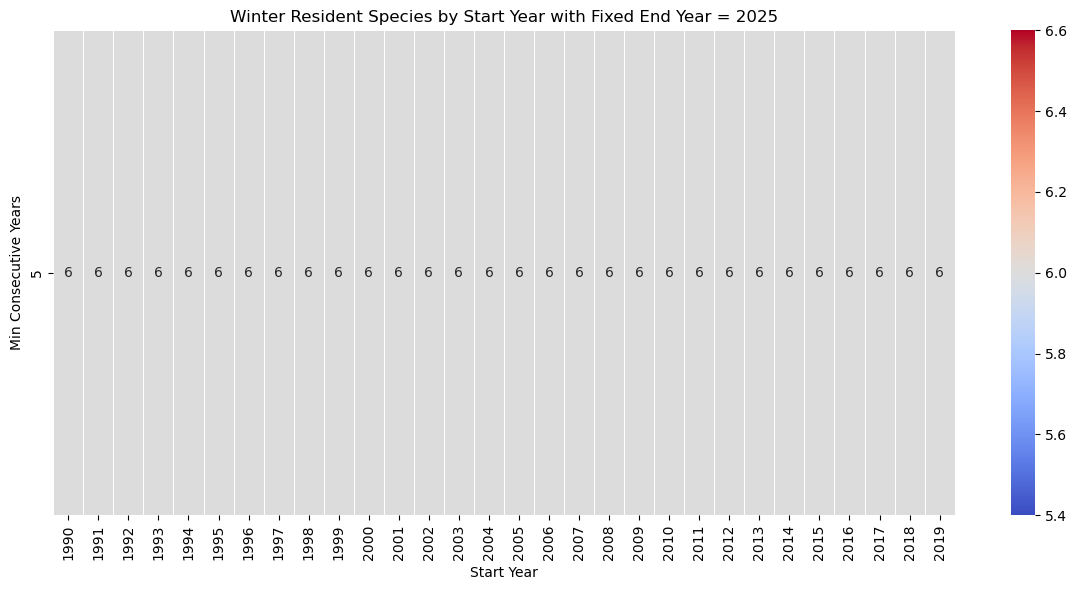

In [11]:
evaluate_combinations_dummy(ebd_path)

Increasing the minimum consecutive years already gives a much worse result:

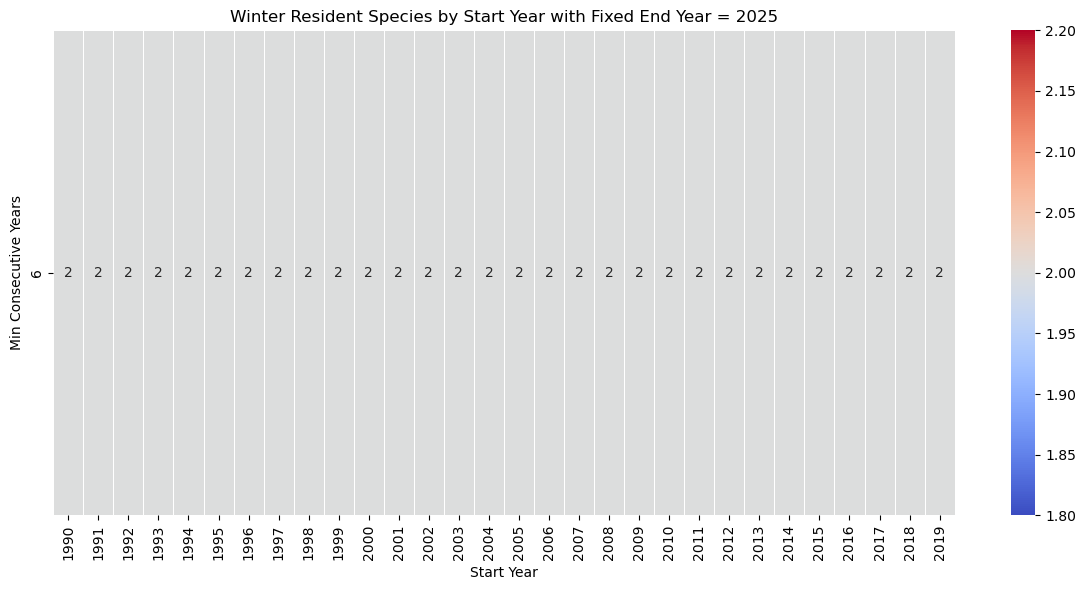

In [12]:
evaluate_combinations_dummy(ebd_path, min_consecutive_years=6)

So, I will settle on $5$ min_consecutive_years, and I will take the most recent start year of $2019$, as already explained, I am interested in the most recent observations, so including the years $2024$ and $2025$ is a priority for me.

In [13]:
df_migratory_birds, sed_migratory_birds = load_and_prepare_data(ebd_path, sed_path)

In [14]:
def plot_species_counts_by_seasonality(
    df_migratory_birds: pd.DataFrame,
    threshold: int = 1500
):
    """
    Plot observation counts per species per year, split by seasonality (summer_breeders, winter_residents),
    and further split species by whether their max yearly observation count is above or below a threshold.
    Each plot's y-axis is scaled to start at the minimum observation count and end at max count in that group.

    Parameters:
        df_migratory_birds (pd.DataFrame): Original DataFrame containing 'common_name', 'seasonality', 'year', and 'observation_count' columns.
        threshold (int): Threshold for max yearly observation count to split species groups.
    """

    # Aggregate counts of observations per species per year
    species_counts = (
        df_migratory_birds.groupby(['year', 'common_name'])['observation_count']
        .sum()
        .reset_index()
    )

    # Merge seasonality info into species_counts (on common_name)
    merged = species_counts.merge(
        df_migratory_birds[['common_name', 'seasonality']].drop_duplicates(),
        on='common_name',
        how='left'
    )

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    seasonality_groups = ['summer_breeder', 'winter_resident']
    titles = ['Summer Breeders', 'Winter Residents']

    for i, season in enumerate(seasonality_groups):
        data_season = merged[merged['seasonality'] == season]

        # Max yearly counts per species in this season
        max_counts = data_season.groupby('common_name')['observation_count'].max()

        below_thresh_species = max_counts[max_counts < threshold].index
        above_thresh_species = max_counts[max_counts >= threshold].index

        # Filter groups
        groups = [
            (below_thresh_species, 'Below Threshold'),
            (above_thresh_species, 'Above or Equal Threshold')
        ]

        for j, (species_group, label) in enumerate(groups):
            data_group = data_season[data_season['common_name'].isin(species_group)]

            ax = axes[i, j]
            sns.lineplot(data=data_group, x='year', y='observation_count', hue='common_name', marker='o', ax=ax)

            ax.set_title(f'{titles[i]} with Max Yearly Observations {label} ({threshold})')
            ax.set_xlabel('Year')
            ax.set_ylabel('Observation Count')

            # Determine y-axis limits based on group data
            if not data_group.empty:
                ymin = data_group['observation_count'].min()
                ymax = data_group['observation_count'].max()
                ax.set_ylim(ymin, ymax * 1.05)

            # Place legend outside to the right
            ax.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

Using the plotting function above, we visualize the filtered number of observations per species, normalized by their maximum yearly count within the selected time frame. This reveals a substantial variation in observation numbers across species—ranging from very high maxima (e.g., approximately $17500$ for a summer breeder) to much lower counts (e.g., around $150$ for the Hen Harrier among the winter residents).

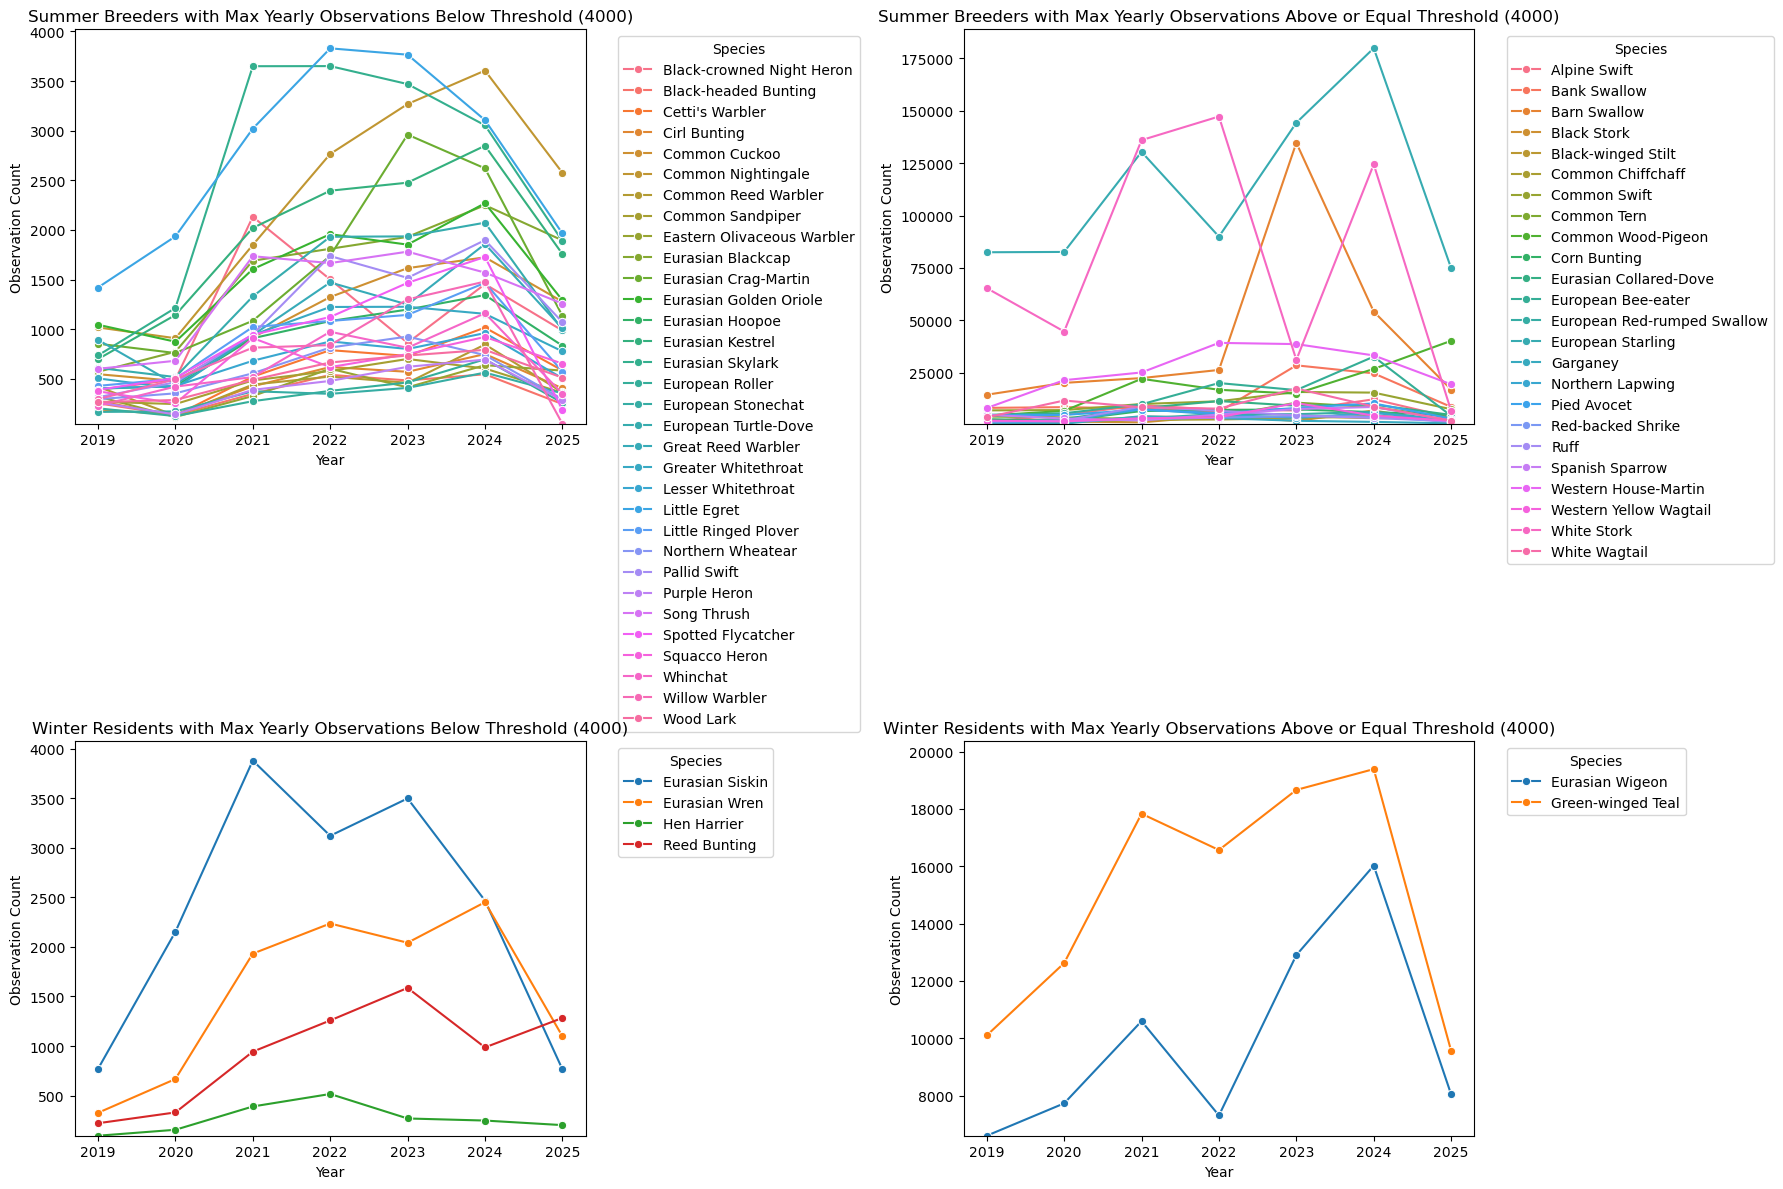

In [15]:
plot_species_counts_by_seasonality(df_migratory_birds, threshold=4000)

All of the cleaning and preprocessing functions are available for import in the ```../src``` folder under the ```bird_data_cleaning.py``` file. 

### Sanity check 

I have composed the following sanity check tests of whether my cleaning function produces meaningful data: 

- date column should be of ``datetime`` type
- month, week, year should be consisent with date column
- ```observation_count``` is integer and non-negative (or NaN for "X")
- ```seasonality``` is restricted only to ```winter_resident``` and ```summer_breeder```, i.e. migratory birds
- no missing values in: ```common_name```, ```scientific_name```, ```observation_count```, ```seasonality```, ```year```, ```month```, ```week```
- ```common_name``` and ```scientific_name``` have a one-to-one relationship
- no species should have total ```observation_count``` of less than $5.150=750$ across all years 

This testing function is available for import from ```../src/bird_data_tests.py```.

In [16]:
def bird_data_tests(df_birds: pd.DataFrame) -> None:
    """
    Run sanity checks on bird observation data.

    Tests include:
    - 'observation_date' is datetime dtype and within a reasonable date range
    - 'observation_count' is either NaN (from 'X') or a non-negative integer
    - 'seasonality' values are within expected categories
    - No missing values in key columns (except 'observation_count')
    - 'common_name' and 'scientific_name' have consistent mappings
    - 'year', 'month', and 'week' match values from 'observation_date'
    - No species with valid counts has total < 750

    Parameters:
        df_birds (pd.DataFrame): Cleaned bird observation DataFrame
    """

    # Check 'observation_date' dtype and range
    assert pd.api.types.is_datetime64_any_dtype(df_birds['observation_date']), "'observation_date' must be datetime dtype"
    min_date, max_date = pd.Timestamp('1900-01-01'), pd.Timestamp.now()
    assert (
        (df_birds['observation_date'] >= min_date) & 
        (df_birds['observation_date'] <= max_date)
    ).all(), "'observation_date' out of expected range"

    # Validate 'observation_count' if not null
    if 'observation_count' in df_birds.columns:
        not_null_counts = df_birds['observation_count'].dropna()
        assert pd.api.types.is_float_dtype(df_birds['observation_count']) or pd.api.types.is_integer_dtype(df_birds['observation_count']), \
            "'observation_count' should be numeric (float or int) even if some values are NaN"
        assert (not_null_counts >= 0).all(), "'observation_count' contains negative values"

    # Validate seasonality labels
    expected = {'summer_breeder', 'winter_resident', 'year_round_resident'}
    actual = set(df_birds['seasonality'].dropna().unique())
    assert actual <= expected, f"Unexpected seasonality values: {actual - expected}"

    # Check for missing critical columns (excluding 'observation_count')
    critical = ['observation_date', 'common_name', 'scientific_name', 'seasonality']
    missing = df_birds[critical].isnull().any()
    assert not missing.any(), f"Missing values in columns: {missing[missing].index.tolist()}"

    # Check 1:1 mapping between names
    common_to_sci = df_birds.groupby('common_name')['scientific_name'].nunique()
    sci_to_common = df_birds.groupby('scientific_name')['common_name'].nunique()
    assert (common_to_sci <= 1).all(), f"Multiple scientific_names per common_name: {common_to_sci[common_to_sci > 1].to_dict()}"
    assert (sci_to_common <= 1).all(), f"Multiple common_names per scientific_name: {sci_to_common[sci_to_common > 1].to_dict()}"

    # Ensure date parts are present
    for col in ['year', 'month', 'week']:
        assert col in df_birds.columns, f"Missing '{col}' column"

    # Match date components to observation_date
    assert (df_birds['year'] == df_birds['observation_date'].dt.year).all(), "'year' column mismatch"
    assert (df_birds['month'] == df_birds['observation_date'].dt.month).all(), "'month' column mismatch"
    assert (df_birds['week'] == df_birds['observation_date'].dt.isocalendar().week).all(), "'week' column mismatch"

    # Check total observation count per species (for non-NaN values)
    valid_counts = df_birds.dropna(subset=['observation_count'])
    species_totals = valid_counts.groupby('common_name')['observation_count'].sum()
    too_low = species_totals[species_totals < 750]
    assert too_low.empty, f"Species with total observations < 150: {too_low.to_dict()}"

    print("All bird data tests passed.")

In [17]:
bird_data_tests(df_migratory_birds)

All bird data tests passed.


The bird data has passed a basic sanity check, so let's now proceed to the weather data.

## Weather data

### Weather data acquisition

Weather data has been acquired as downloads from the [NOAA website](https://www.ncei.noaa.gov/access/search/data-search/global-summary-of-the-day) and it informs on the below features. Information is found on the NOAA website, and downloaded in a docs file available under ```../data/raw/weather_data/docs_weather_data.txt```.

| Feature               | Description                                                                                                                     |
| --------------------- | ------------------------------------------------------------------------------------------------------------------------------- |
| **STATION**           | Station ID (WMO/DATSAV3, possibly with WBAN number).                                                                            |
| **DATE**              | Date of observation (mm/dd/yyyy, GMT-based).                                                                                    |
| **LATITUDE**          | Latitude in decimal degrees (negative for south).                                                                               |
| **LONGITUDE**         | Longitude in decimal degrees (negative for west).                                                                               |
| **ELEVATION**         | Elevation of station in meters.                                                                                                 |
| **NAME**              | Station, airport, or base name.                                                                                                 |
| **TEMP**              | Mean daily temperature (°F, 0.1 precision).                                                                                     |
| **TEMP\_ATTRIBUTES**  | Number of observations used for mean temperature.                                                                               |
| **DEWP**              | Mean daily dew point (°F, 0.1 precision).                                                                                       |
| **DEWP\_ATTRIBUTES**  | Number of observations used for mean dew point.                                                                                 |
| **SLP**               | Mean daily sea level pressure (mb, 0.1 precision).                                                                              |
| **SLP\_ATTRIBUTES**   | Number of observations used for mean sea level pressure.                                                                        |
| **STP**               | Mean daily station pressure (mb, 0.1 precision).                                                                                |
| **STP\_ATTRIBUTES**   | Number of observations used for mean station pressure.                                                                          |
| **VISIB**             | Mean daily visibility (miles, 0.1 precision).                                                                                   |
| **VISIB\_ATTRIBUTES** | Number of observations used for mean visibility.                                                                                |
| **WDSP**              | Mean daily wind speed (knots, 0.1 precision).                                                                                   |
| **WDSP\_ATTRIBUTES**  | Number of observations used for mean wind speed.                                                                                |
| **MXSPD**             | Maximum sustained wind speed (knots, 0.1 precision).                                                                            |
| **GUST**              | Maximum wind gust (knots, 0.1 precision).                                                                                       |
| **MAX**               | Maximum temperature reported for the day (°F, 0.1 precision).                                                                   |
| **MAX\_ATTRIBUTES**   | Source indicator: blank = explicit max report, \* = from hourly data.                                                           |
| **MIN**               | Minimum temperature reported for the day (°F, 0.1 precision).                                                                   |
| **MIN\_ATTRIBUTES**   | Source indicator: blank = explicit min report, \* = from hourly data.                                                           |
| **PRCP**              | Total daily precipitation (inches, 0.01 precision).                                                                             |
| **PRCP\_ATTRIBUTES**  | Code indicating reporting method (A–I).                                                                                         |
| **SNDP**              | Snow depth at day's end (inches, 0.1 precision).                                                                                |
| **FRSHTT**            | Six-digit weather occurrence flags: Fog, Rain/Drizzle, Snow/Ice Pellets, Hail, Thunder, Tornado/Funnel Cloud (1 = yes, 0 = no). |

### Weather data loading, cleaning and preprocessing

I have downloaded data for two periods - from January 01 1955 to December 31 1989 and from January 01 1990 to June 30 2025. This is the full data available for Bulgaria. I have split it into two equal time intervals, due to maximum download size restrictions on the NOAA website. Here are the file paths for both of those:

In [18]:
baseline_weather_path = "../data/raw/weather_data/weather_data_noaa_1955-1989.csv"

In [19]:
weather_path = "../data/raw/weather_data/weather_data_noaa_1990-2025.csv"

In [20]:
test = pd.read_csv(weather_path) 

test['FRSHTT'].unique()

array([     0, 100000, 110000,  10000, 101000,   1000, 111000,  11000,
       111010, 100010,  10010,     10, 110010, 110100,  10110,  11010,
       110110,   1010, 111100, 111110,  10100, 101010,  11100,      1,
        10111,     11,  10011, 100001,  11110, 110001,  10001, 101001])

The first thing I notice is that on the datasets themselves the FRSHTT feature doesn't have any encodings with less than $6$ digits. However, leading zeros are removed when loading into a dataframe, and we are left with the above set of values. This will be handled via the cleaning and preprocessing step.

To clean and preprocess the data, I have defined a few helper functions for unit conversions ```fahrenheit_to_celcius```, ```miles_to_km```, ```knots_to_kmh``` and ```inch_to_mm```. 

To clean the weather data I have created the ```clean_noaa_data``` function that: 

- pythonizes column names
- converts units with the helper functions
- converts missing values (as outlined in the docs file) to ```np.nan```
- adds leading zeros to the FRSHTT column entries (as explained above)
- creates binary columns for fog, rain, snow, hail, thunder and tornado that denote presence ($1$) or absense ($0$) of the weather event based on FRSHTT
- define features ```wet_day``` and ```snow_day``` based on the positive prcp_mm and sndp respectively; this is useful because on FRSHTT $0$ could also mean not reported, and we cannot be ultimately sure about the absence of e.g. rain when the second digit is a zero
- define ```gale_day``` as day in which windspeed exceeds [$50$kmh](https://en.wikipedia.org/wiki/Gale) and ```fog_day``` as a day in which [visibility is under one kilometer](https://en.wikipedia.org/wiki/Fog)
- converts date to ```pandas``` ```datetime```; also extract month, year, week number and season to match what I did on the bird dataframe above


In [21]:
# Helper functions that can either take inputs a single column from a dataframe (Series or multi-dimensional array ndarray). return same type as input

def fahrenheit_to_celsius(temp: Union[pd.Series, np.ndarray]) -> Union[pd.Series, np.ndarray]:
    """
    Convert temperature from Fahrenheit to Celsius.

    Parameters:
        temp (pd.Series or np.ndarray): Temperature(s) in Fahrenheit.

    Returns:
        pd.Series or np.ndarray: Temperature(s) converted to Celsius.
    """
    return (temp.astype(float) - 32) * 5.0 / 9.0


def miles_to_km(dist: Union[pd.Series, np.ndarray]) -> Union[pd.Series, np.ndarray]:
    """
    Convert distance from miles to kilometers.

    Parameters:
        dist (pd.Series or np.ndarray): Distance(s) in miles.

    Returns:
        pd.Series or np.ndarray: Distance(s) converted to kilometers.
    """
    return dist.astype(float) * 1.609344


def knots_to_kmh(speed: Union[pd.Series, np.ndarray]) -> Union[pd.Series, np.ndarray]:
    """
    Convert speed from knots to kilometers per hour.

    Parameters:
        speed (pd.Series or np.ndarray): Speed(s) in knots.

    Returns:
        pd.Series or np.ndarray: Speed(s) converted to km/h.
    """
    return speed.astype(float) * 1.852


def inch_to_mm(amount: Union[pd.Series, np.ndarray]) -> Union[pd.Series, np.ndarray]:
    """
    Convert length from inches to millimeters.

    Parameters:
        amount (pd.Series or np.ndarray): Length(s) in inches.

    Returns:
        pd.Series or np.ndarray: Length(s) converted to millimeters.
    """
    return amount.astype(float) * 25.4

# Clean NOAA data function 

def clean_noaa_data(df: DataFrame) -> DataFrame:
    """
    Clean GSOD weather data DataFrame:
    - Replace known missing value placeholders with NaN.
    - Parse and decode the FRSHTT weather flags into separate boolean columns.
    - Normalize column names.
    - Convert dates and extract year, month, week, and season.
    - Convert various units to metric.
    - Create additional binary flags for weather conditions.

    Parameters:
        df (DataFrame): Raw GSOD weather data.

    Returns:
        DataFrame: Cleaned and enriched weather data.
    """
    # Replace known missing value placeholders with NaN
    missing_vals = [9999.9, 999.9, 99.99, 999.0, 9999.0, 999.0, 99.9, 999]
    df = df.replace(missing_vals, np.nan)

    # Pythonize column names to lowercase with underscores
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(' ', '_')
        .str.replace('-', '_')
    )

    # Add leading zeros to ensure 6 digits
    df['frshtt'] = df['frshtt'].astype(str).str.zfill(6)

    # Decode FRSHTT flags: Fog, Rain, Snow, Hail, Thunder, Tornado
    df['fog'] = df['frshtt'].str[0].astype(int)
    df['rain'] = df['frshtt'].str[1].astype(int)
    df['snow'] = df['frshtt'].str[2].astype(int)
    df['hail'] = df['frshtt'].str[3].astype(int)
    df['thunder'] = df['frshtt'].str[4].astype(int)
    df['tornado'] = df['frshtt'].str[5].astype(int)

    # Parse dates and extract year, month, week
    df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce')
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['week'] = df['date'].dt.isocalendar().week

    # Map months to seasons the same way as with the bird data
    df['season'] = df['month'].map({
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
    })

    # Convert temperatures from Fahrenheit to Celsius
    df['temp_c'] = fahrenheit_to_celsius(df['temp'])
    df['max_c'] = fahrenheit_to_celsius(df['max'])
    df['min_c'] = fahrenheit_to_celsius(df['min'])
    df['dewp_c'] = fahrenheit_to_celsius(df['dewp'])

    # Convert visibility from miles to kilometers
    df['visib_km'] = miles_to_km(df['visib'])

    # Convert wind speeds from knots to km/h
    df['wdsp_kmh'] = knots_to_kmh(df['wdsp'])
    df['mxspd_kmh'] = knots_to_kmh(df['mxspd'])
    df['gust_kmh'] = knots_to_kmh(df['gust'])

    # Convert precipitation and snow depth from inches to millimeters
    df['prcp_mm'] = inch_to_mm(df['prcp'])
    df['sndp_mm'] = inch_to_mm(df['sndp'])

    # Create further binary flags for weather conditions
    df['wet_day'] = (df['prcp_mm'] > 0).astype(int)
    df['snow_day'] = (df['sndp_mm'] > 0).astype(int)
    df['gale_day'] = (df['wdsp_kmh'] > 50).astype(int)
    df['fog_day'] = (df['visib_km'] < 1).astype(int)

    return df

I will load and prepare all weather data for analysis via ```load_and_prepare_weather_data```. I will call the more recent period the **analysis** period, as it will serve to me as current weather data that matches the period of bird observations. The older period I will call **baseline** and will explore further how could I use it to see long-term changes in weather variables. 

In [22]:
def load_and_prepare_weather_data(
    filepath: str, 
    filepath_baseline: str
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load raw NOAA GSOD weather data CSV files, clean and preprocess them.

    This function reads two CSV files containing weather data, applies cleaning
    and preprocessing using the `clean_noaa_data` function, and returns the cleaned DataFrames.

    Parameters:
        filepath (str): Path to the main NOAA GSOD CSV file.
        filepath_baseline (str): Path to the baseline NOAA GSOD CSV file.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: A tuple containing two cleaned DataFrames:
            - The main weather dataset.
            - The baseline weather dataset.
    """
    df = pd.read_csv(filepath)
    df_baseline = pd.read_csv(filepath_baseline)
    df = clean_noaa_data(df)
    df_baseline = clean_noaa_data(df_baseline)
    return df, df_baseline

In [23]:
df_weather_data_1955_1989, df_weather_data_1990_2025  = load_and_prepare_weather_data(weather_path, baseline_weather_path)

All of the weather cleaning and preprocessing function are available for import in ```../src/weather_data_cleaning.py```.

### Sanity check

I have composed the following sanity check tests of whether my cleaning function produces meaningful data:

- that all temperatures in degrees Celcius are between the minimum measures temperature and maximum measured temperature in Bulgaria ([source](https://en.wikipedia.org/wiki/Bulgaria)
- that ```temp_c``` is between ```min_c``` and ```max_c``` for all observations
- date column should be of ``datetime`` type
- month, week, year should be consisent with date column
- weather flags should be binary
- precipitation, snow depth, visibility and wind speed should not be negative, and the newly created features from them should be consistent
- column names are indeed more Pythonic
- baseline period is before main data period for analysis

This testing function is available in ```../src/weather_data_tests.py```

In [24]:
def weather_data_tests(df: pd.DataFrame, df_baseline: pd.DataFrame) -> None:
    """
    Run comprehensive tests on cleaned NOAA GSOD weather dataframes.

    Tests include:
    - Temperature range validity for Bulgaria
    - 'temp_c' consistency with 'min_c' and 'max_c'
    - Date and derived columns consistency
    - Weather flags are binary
    - Non-negative precipitation, snow depth, visibility, and wind speeds
    - Logical consistency of wet_day, snow_day, gale_day, fog_day flags
    - Column name normalization (lowercase, no spaces or hyphens)

    Parameters:
        df (pd.DataFrame): Cleaned main weather dataframe
        df_baseline (pd.DataFrame): Cleaned baseline weather dataframe
    """

    def _run_tests(df_clean: pd.DataFrame, name: str) -> None:
        # Temperature range checks (skip NA)
        assert df_clean['min_c'].dropna().ge(-38.4).all(), f"{name}: 'min_c' below -38.4°C found"
        assert df_clean['max_c'].dropna().le(45.3).all(), f"{name}: 'max_c' above 45.3°C found"
        
        # temp_c should lie between min_c and max_c
        mask = df_clean[['temp_c', 'min_c', 'max_c']].notna().all(axis=1)
        temp = df_clean.loc[mask, 'temp_c']
        min_t = df_clean.loc[mask, 'min_c']
        max_t = df_clean.loc[mask, 'max_c']
        assert (temp >= min_t).all() and (temp <= max_t).all(), f"{name}: 'temp_c' outside min/max range"

        # Date columns check
        assert pd.api.types.is_datetime64_any_dtype(df_clean['date']), f"{name}: 'date' is not datetime dtype"
        assert (df_clean['year'] == df_clean['date'].dt.year).all(), f"{name}: 'year' inconsistent with 'date'"
        assert (df_clean['month'] == df_clean['date'].dt.month).all(), f"{name}: 'month' inconsistent with 'date'"
        assert (df_clean['week'] == df_clean['date'].dt.isocalendar().week).all(), f"{name}: 'week' inconsistent with 'date'"

        # Weather flags binary check
        for col in ['fog', 'rain', 'snow', 'hail', 'thunder', 'tornado']:
            unique_vals = df_clean[col].dropna().unique()
            assert set(unique_vals).issubset({0, 1}), f"{name}: Column '{col}' has non-binary values {unique_vals}"

        # Non-negative precipitation and snow depth
        assert (df_clean['prcp_mm'].dropna() >= 0).all(), f"{name}: 'prcp_mm' has negative values"
        assert (df_clean['sndp_mm'].dropna() >= 0).all(), f"{name}: 'sndp_mm' has negative values"

        # Non-negative visibility and wind speeds
        for col in ['visib_km', 'wdsp_kmh', 'mxspd_kmh', 'gust_kmh']:
            assert (df_clean[col].dropna() >= 0).all(), f"{name}: '{col}' has negative values"

        # Logical consistency of wet_day, snow_day, gale_day, fog_day
        assert ((df_clean['wet_day'] == 1) == (df_clean['prcp_mm'] > 0)).all(), f"{name}: 'wet_day' inconsistent with 'prcp_mm'"
        assert ((df_clean['snow_day'] == 1) == (df_clean['sndp_mm'] > 0)).all(), f"{name}: 'snow_day' inconsistent with 'sndp_mm'"
        assert ((df_clean['gale_day'] == 1) == (df_clean['wdsp_kmh'] > 50)).all(), f"{name}: 'gale_day' inconsistent with 'wdsp_kmh'"
        assert ((df_clean['fog_day'] == 1) == (df_clean['visib_km'] < 1)).all(), f"{name}: 'fog_day' inconsistent with 'visib_km'"

        # Column name normalization
        for col in df_clean.columns:
            assert col == col.lower(), f"{name}: Column '{col}' not lowercase"
            assert ' ' not in col, f"{name}: Column '{col}' contains spaces"
            assert '-' not in col, f"{name}: Column '{col}' contains hyphens"

    # Run tests on both dataframes
    _run_tests(df, 'Main df')
    _run_tests(df_baseline, 'Baseline df')

    # Check that baseline period ends before main data period starts
    baseline_max_date = df_baseline['date'].max()
    main_min_date = df['date'].min()
    assert baseline_max_date < main_min_date, (
        f"Baseline period ends at {baseline_max_date.date()}, which is not before "
        f"main data period start {main_min_date.date()}"
    )

    print("All tests passed")

In [25]:
weather_data_tests(df_weather_data_1955_1989, df_weather_data_1990_2025)

All tests passed


Okay, so the weather data has passed basic sanity checks. I am ready to proceed to the Exploratory Data analysis and feature engineering part, available in [this notebook](exploratory_data_analysis_and_feature_engineering.ipynb) .

## Works Cited or Considered

- Cornell Lab of Ornithology, n.d. “eBird Login.” [https://secure.birds.cornell.edu/cassso/login?service=https%3A%2F%2Febird.org%2Flogin%2Fcas%3Fportal%3Debird&locale=en_US](https://secure.birds.cornell.edu/cassso/login?service=https%3A%2F%2Febird.org%2Flogin%2Fcas%3Fportal%3Debird&locale=en_US) (accessed Aug. 2025).  
- SciELO, n.d. “Accurate species distribution models in the Caatinga biome.” [https://www.scielo.br/j/aabc/a/GyphZPPwgPx6mZ8zVcQnGQC/?lang=en](https://www.scielo.br/j/aabc/a/GyphZPPwgPx6mZ8zVcQnGQC/?lang=en) (accessed Aug. 2025).  
- Quora, n.d. “Is Bulgaria a Southern country and does it have a mild climate?” [https://www.quora.com/Is-Bulgaria-a-Southern-country-and-does-it-have-a-mild-climate](https://www.quora.com/Is-Bulgaria-a-Southern-country-and-does-it-have-a-mild-climate) (accessed Aug. 2025).  
- WorldData.info, n.d. “Country comparison: Bulgaria / Spain.” [https://www.worlddata.info/climate-comparison.php?r1=bulgaria&r2=spain](https://www.worlddata.info/climate-comparison.php?r1=bulgaria&r2=spain) (accessed Aug. 2025).  
- Green Balkans, n.d. “Storks in winter.” [https://greenbalkans.org/bg/Shtyrkeli_prez_zimata-p4144](https://greenbalkans.org/bg/Shtyrkeli_prez_zimata-p4144) (accessed Aug. 2025).  
- KarlovoBG.eu, n.d. “Town of Karlovo local news.” [http://www.karlovobg.eu/index.php?option=com_content&view=article&id=9512:2015-12-22-18-09-00](http://www.karlovobg.eu/index.php?option=com_content&view=article&id=9512:2015-12-22-18-09-00) (accessed Aug. 2025).  
- Wiley BES Journals, n.d. “Bird migration and population ecology.” [https://besjournals.onlinelibrary.wiley.com/doi/full/10.1111/1365-2656.13641](https://besjournals.onlinelibrary.wiley.com/doi/full/10.1111/1365-2656.13641) (accessed Aug. 2025).  
- Frontiers in Veterinary Science, 2025. “Recent studies in avian health and migration patterns.” [https://www.frontiersin.org/journals/veterinary-science/articles/10.3389/fvets.2025.1584864/full](https://www.frontiersin.org/journals/veterinary-science/articles/10.3389/fvets.2025.1584864/full) (accessed Aug. 2025).  
- Wikipedia contributors, 2025a. “Season,” *Wikipedia*. [https://en.wikipedia.org/wiki/Season](https://en.wikipedia.org/wiki/Season) (accessed Aug. 2025).  
- NOAA NCEI, n.d. “Global Summary of the Day (GSOD) dataset.” [https://www.ncei.noaa.gov/access/search/data-search/global-summary-of-the-day](https://www.ncei.noaa.gov/access/search/data-search/global-summary-of-the-day) (accessed Aug. 2025).  
- Wikipedia contributors, 2025b. “Fog,” *Wikipedia*. [https://en.wikipedia.org/wiki/Fog](https://en.wikipedia.org/wiki/Fog) (accessed Aug. 2025).  
- Wikipedia contributors, 2025c. “Gale,” *Wikipedia*. [https://en.wikipedia.org/wiki/Gale](https://en.wikipedia.org/wiki/Gale) (accessed Aug. 2025).  
- Wikipedia contributors, 2025d. “Bulgaria,” *Wikipedia*. [https://en.wikipedia.org/wiki/Bulgaria](https://en.wikipedia.org/wiki/Bulgaria) (accessed Aug. 2025).  




